# Where the waffles are: five states hold most of Waffle House

**Finding (plain English):** More than half of all U.S. Waffle House locations
sit in just **five Southeastern states** — Georgia, Florida, North Carolina,
South Carolina, and Alabama. Georgia alone has more than one in five.

This notebook reproduces that finding **from the raw data file**, top to bottom:
it documents the source, runs data-quality checks, computes the numbers, charts
them, and closes with limitations — so an editor can re-run and verify every step.

*Author's note: every number below is produced by the code in this notebook. Nothing is typed in by hand.*


## 1 · Data source

| | |
|---|---|
| **File** | `waffle_houses.csv` (in this folder) |
| **What it is** | One row per Waffle House location, scraped from the company's public store locator |
| **Rows** | 2,006 locations |
| **Key columns** | `Store Code`, `Business Name`, `City`, `State`, `Latitude`, `Longitude`, `Operated By` |
| **Retrieved** | Snapshot used for this analysis dated 2026 |
| **Full column docs** | see `DATA_DICTIONARY.md` in this folder |

The file is read directly below — no manual editing, no intermediate spreadsheet.


In [1]:
import pandas as pd

df = pd.read_csv(
    "waffle_houses.csv",
    dtype={"Store Code": str, "Postal Code": str},  # IDs/ZIPs are strings, not numbers
)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)


Loaded 2,006 rows, 14 columns


,Store Code,Business Name,Address,City,State,Postal Code,Country,Latitude,Longitude,Phone Number,Website URL,Operated By,Online Order Link,Formatted Business Hours
0,100,Waffle House #100,2842 PANOLA RD,LITHONIA,GA,30058,US,33.704706,-84.169849,(770) 981-1914,https://locations.wafflehouse.com///lithonia-g...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
1,1000,Waffle House #1000,2850 E COLLEGE AVE,DECATUR,GA,30030,US,33.775215,-84.273744,(404) 294-8758,https://locations.wafflehouse.com///decatur-ga...,"WAFFLE HOUSE, INC",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours
2,1001,Waffle House #1001,12923 SHELBYVILLE RD,LOUISVILLE,KY,40243,US,38.243594,-85.513206,(502) 244-1005,https://locations.wafflehouse.com///louisville...,"FULLY OWNED SUBSIDIARY: MIDWEST WAFFLES, INC.",https://order.wafflehouse.com/menu/waffle-hous...,Monday - Sunday| 24 hours


## 2 · Data-quality checks (before trusting anything)

Quality checks are the first half of fact-checking. Before counting, we confirm
the columns we rely on (`State`, `Store Code`) are clean, and we surface the
known oddities documented in `DATA_DICTIONARY.md`.


In [2]:
# 2a. Missing values per column
missing = df.isna().sum()
print("Columns with blanks:")
print(missing[missing > 0].to_string() or "  (none)")


Columns with blanks:
Operated By                 1
Online Order Link           3
Formatted Business Hours    2


In [3]:
# 2b. Is every location assigned to a state? (the column our finding depends on)
print("Blank State values:", df["State"].isna().sum())
print("Distinct states present:", df["State"].nunique())

# 2c. Are Store Codes unique? (no double-counting)
dupes = df["Store Code"].duplicated().sum()
print("Duplicate Store Codes:", dupes)


Blank State values: 0
Distinct states present: 25
Duplicate Store Codes: 0


In [4]:
# 2d. Known flagged rows (from DATA_DICTIONARY.md):
#     - the Waffle House Museum (not a normal restaurant)
#     - the #442/#3442 same-site duplicate in Baton Rouge
#     - 2 stores marked "Closed"
flags = df[
    (df["Store Code"] == "WH_Museum")
    | (df["Store Code"].isin(["442", "3442"]))
    | (df["Formatted Business Hours"].fillna("").str.contains("Closed"))
]
print(f"{len(flags)} flagged rows:")
flags[["Store Code", "Business Name", "City", "State", "Formatted Business Hours"]]


5 flagged rows:


,Store Code,Business Name,City,State,Formatted Business Hours
1457,2473,Waffle House #2473,XENIA,OH,Monday - Sunday| Closed
1459,2475,Waffle House #2475,BUCHANAN,GA,Monday - Sunday| Closed
1517,3442,Waffle House #3442,BATON ROUGE,LA,NaN
1581,442,Waffle House #442,BATON ROUGE,LA,Monday - Sunday| 24 hours
2005,WH_Museum,Waffle House Museum #WH_Museum,Decatur,GA,NaN


**QA result:** `State` has zero blanks, all 2,006 `Store Code`s are unique (no
double-counting), and the only oddities are 5 flagged rows. None of the flagged
rows change the state ranking materially (the museum is in GA; the duplicate
pair is in LA), so we keep all 2,006 rows and note this in *Limitations*.


## 3 · Reproduce the finding, step by step

### 3a. Count locations per state


In [5]:
state_counts = df["State"].value_counts()          # rows per state, descending
total = len(df)
state_counts.head(10)


State
GA    442
FL    188
NC    186
SC    175
AL    156
TN    139
TX    127
LA    103
MS     88
OH     83
Name: count, dtype: int64

### 3b. Georgia's share of the national total

In [6]:
top_state = state_counts.index[0]
top_n = int(state_counts.iloc[0])
top_pct = 100 * top_n / total
print(f"{top_state}: {top_n:,} of {total:,} locations = {top_pct:.1f}%")


GA: 442 of 2,006 locations = 22.0%


### 3c. The top five states combined

In [7]:
top5 = state_counts.head(5)
top5_n = int(top5.sum())
top5_pct = 100 * top5_n / total

calc = " + ".join(f"{int(c)} ({s})" for s, c in top5.items())
print(f"Top 5: {calc}")
print(f"     = {top5_n:,} of {total:,} = {top5_pct:.1f}% of all Waffle Houses")


Top 5: 442 (GA) + 188 (FL) + 186 (NC) + 175 (SC) + 156 (AL)
     = 1,147 of 2,006 = 57.2% of all Waffle Houses


**The finding, confirmed:** the five states above hold more than half of all
locations — reproduced straight from the raw file. The exact percentage is
printed by the cell above and rendered into the chart title below, so the prose
can never drift from the data.


## 4 · Chart the concentration

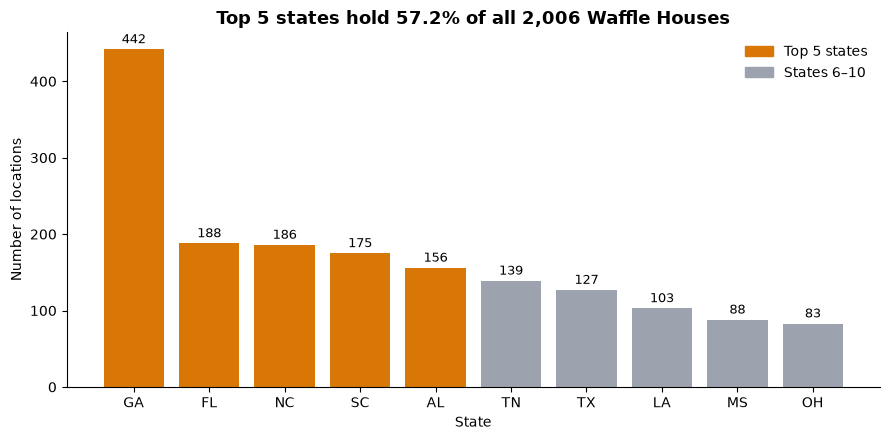

In [8]:
import matplotlib.pyplot as plt

top10 = state_counts.head(10)
colors = ["#d97706" if s in top5.index else "#9ca3af" for s in top10.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(top10.index, top10.values, color=colors)
ax.set_title(f"Top 5 states hold {top5_pct:.1f}% of all {total:,} Waffle Houses",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Number of locations")
ax.set_xlabel("State")
for b, v in zip(bars, top10.values):
    ax.text(b.get_x() + b.get_width()/2, v + 4, f"{int(v)}",
            ha="center", va="bottom", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
# Legend proxy
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#d97706", label="Top 5 states"),
                   Patch(color="#9ca3af", label="States 6–10")],
          frameon=False)
plt.tight_layout()
plt.savefig("top5_states.png", dpi=120, bbox_inches="tight")
plt.show()


## 5 · Limitations & caveats

- **Snapshot in time.** The file is a single scrape of the public store locator.
  Stores open and close; counts will drift.
- **"Locations," not "open restaurants."** All 2,006 rows are counted. That
  includes the **Waffle House Museum** (`WH_Museum`, Decatur GA — not a working
  restaurant), a **same-site duplicate** (#442/#3442 in Baton Rouge, two store
  codes at one address ~186 ft apart), and **2 stores marked "Closed."** Net of
  these, ~2,004 distinct operating restaurants. None of them change the top-5
  ranking, but exact percentages shift by <0.1 pt.
- **Coverage = U.S. only.** Every row is `Country = US`; 25 of 50 states have
  zero locations. The finding is about the U.S. footprint, not global.
- **Self-reported geography.** State assignment comes from the company's own
  data; we did not independently geocode addresses. Latitude/longitude were
  sanity-checked to fall within U.S. bounds (see `DATA_DICTIONARY.md`).
- **No population adjustment.** This is raw counts. "Most Waffle Houses" is not
  the same as "most per capita" — a different (and also interesting) question.

## Reproducibility
Re-run this notebook top to bottom (`Kernel → Restart & Run All`) against
`waffle_houses.csv` to regenerate every number and the chart. Source columns are
documented in `DATA_DICTIONARY.md`; the same figures appear in `ANALYSIS.md`.
